# NB10 — Active Learning Proposal: Next Experiments for ENIGMA

**Project**: `genotype_to_phenotype_enigma`
**Depends on**: `NB09_conflict_detection.ipynb` (consumes `data/active_learning_candidates.tsv`)

## Goal

Convert the 343-condition ranked candidate list from NB09 into a concrete 50-experiment proposal for ENIGMA's next growth screen, weighted by **Oak Ridge field relevance**.

## Scoring

For each condition:

1. **`al_score`** (from NB09) = `error_rate × (1 − mean_confidence)`
2. **`field_weight`** = `2.0` if the condition matches Oak Ridge geochemistry (organic acids from necromass decomposition, nitrogen-cycle compounds, aromatic compounds, low-pH-compatible substrates); else `1.0`
3. **`weighted_score`** = `al_score × field_weight`

Top 50 by `weighted_score` is the proposal.

## Field relevance definition

The Oak Ridge Y-12 plume is characterized by:

- **Nitric acid-driven low pH** (nitric and related nitrogen species from historic uranium extraction)
- **Organic acid accumulation** in necromass-rich plume sediments (TCA cycle intermediates, fatty acids, amino acids)
- **Aromatic compounds** from lignin degradation (necromass and soil organic matter)

Substrates that match these profiles are weighted 2×; sugar alcohols, complex sugars, and detergents are weighted 1×.

The rule here is substring / suffix based — `'acid'` anywhere in the condition name, plus a whitelist of conjugate-base suffixes (`fumarate`, `pyruvate`, `glutamate`, `aspartate`, `citrate`, `malate`, `succinate`, `lactate`, `formate`, `itaconate`, `oxalate`, `citramalate`, `glyoxylate`, `nacetyllglutamate`, `nitrate`, `nitrite`), plus an explicit single-entry list (`n2acetylglutamine` as an n-acetyl amino acid representative). Sugar phosphates, sulfates, detergents, and short-chain fatty acids are intentionally excluded — they exist in necromass but are not the priority targets for the Oak Ridge screen.


In [1]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

DATA = Path('../data')
FIG = Path('../figures')
FIG.mkdir(exist_ok=True)

pd.set_option('display.max_rows', 60)
pd.set_option('display.width', 200)


## 1. Field-relevance rule

In [2]:
FIELD_RELEVANT_ATE_SUFFIXES = (
    'fumarate', 'pyruvate', 'glutamate', 'aspartate', 'citramalate',
    'glyoxylate', 'nacetyllglutamate', 'citrate', 'malate', 'succinate',
    'lactate', 'formate', 'itaconate', 'oxalate', 'nitrate', 'nitrite',
)
EXPLICIT_FIELD_RELEVANT = {'n2acetylglutamine'}

def field_weight(cond: str) -> float:
    c = str(cond).lower().replace('-', '').replace('_', '')
    if c in EXPLICIT_FIELD_RELEVANT:
        return 2.0
    if 'acid' in c:
        return 2.0
    for sfx in FIELD_RELEVANT_ATE_SUFFIXES:
        if re.search(sfx + r'\d*$', c):
            return 2.0
    return 1.0

# Sanity check
assert field_weight('fumaricacid') == 2.0
assert field_weight('nitrate') == 2.0
assert field_weight('n2acetylglutamine') == 2.0
assert field_weight('adonitol') == 1.0
assert field_weight('glucose-6-phosphate') == 1.0  # phosphate not treated as organic acid
assert field_weight('polysorbate20') == 1.0  # detergent not included
print('Field-weight rule sanity checks pass.')


Field-weight rule sanity checks pass.


## 2. Apply weights and rank

In [3]:
cands = pd.read_csv(DATA / 'active_learning_candidates.tsv', sep='\t')
cands['field_weight'] = cands['condition'].map(field_weight)
cands['weighted_score'] = cands['al_score'] * cands['field_weight']

# Sort and pick top 50
proposed = (cands.sort_values('weighted_score', ascending=False)
                 .head(50)
                 .reset_index(drop=True))

print(f'Candidates: {len(cands)}')
print(f'Field-relevant (2x): {(cands.field_weight == 2.0).sum()}')
print(f'Non-field-relevant (1x): {(cands.field_weight == 1.0).sum()}')
print()
print('Proposed top-50 distribution:')
print(proposed.groupby(['condition_class','field_weight']).size().unstack(fill_value=0))


Candidates: 363
Field-relevant (2x): 120
Non-field-relevant (1x): 243

Proposed top-50 distribution:
field_weight     1.0  2.0
condition_class          
amino_acid         0    3
carbon             2    3
nitrogen           0    1
other              3   38


In [4]:
# Save proposal
proposed.to_csv(DATA / 'proposed_experiments.tsv', sep='\t', index=False)
print(f'Saved -> data/proposed_experiments.tsv ({len(proposed)} rows)')
print()
print('Top 10:')
proposed.head(10)[['condition','condition_class','al_score','field_weight','weighted_score']].round(3)


Saved -> data/proposed_experiments.tsv (50 rows)

Top 10:


,condition,condition_class,al_score,field_weight,weighted_score
0,fumaricacid,other,0.431,2.0,0.862
1,fumaric-acid,other,0.425,2.0,0.849
2,itaconic-acid,other,0.425,2.0,0.849
3,melibionic-acid,other,0.425,2.0,0.849
4,2hydroxypropanoicacid,other,0.407,2.0,0.815
5,hydroxy-glutaric-acid-g-lactone,other,0.403,2.0,0.807
6,difumarate,other,0.396,2.0,0.793
7,lglutamicacid,other,0.390,2.0,0.780
8,nitrate,nitrogen,0.390,2.0,0.779
9,pyruvicacid,other,0.386,2.0,0.771


## 3. Figure: proposal summary

Two-panel figure:

- **Left**: count of proposed experiments by condition class (shows the proposal is dominated by `other` — mostly organic acids — with secondary contributions from carbon sources, amino acids, and nitrogen).
- **Right**: top-25 individual experiments as horizontal bars, colored by field relevance.


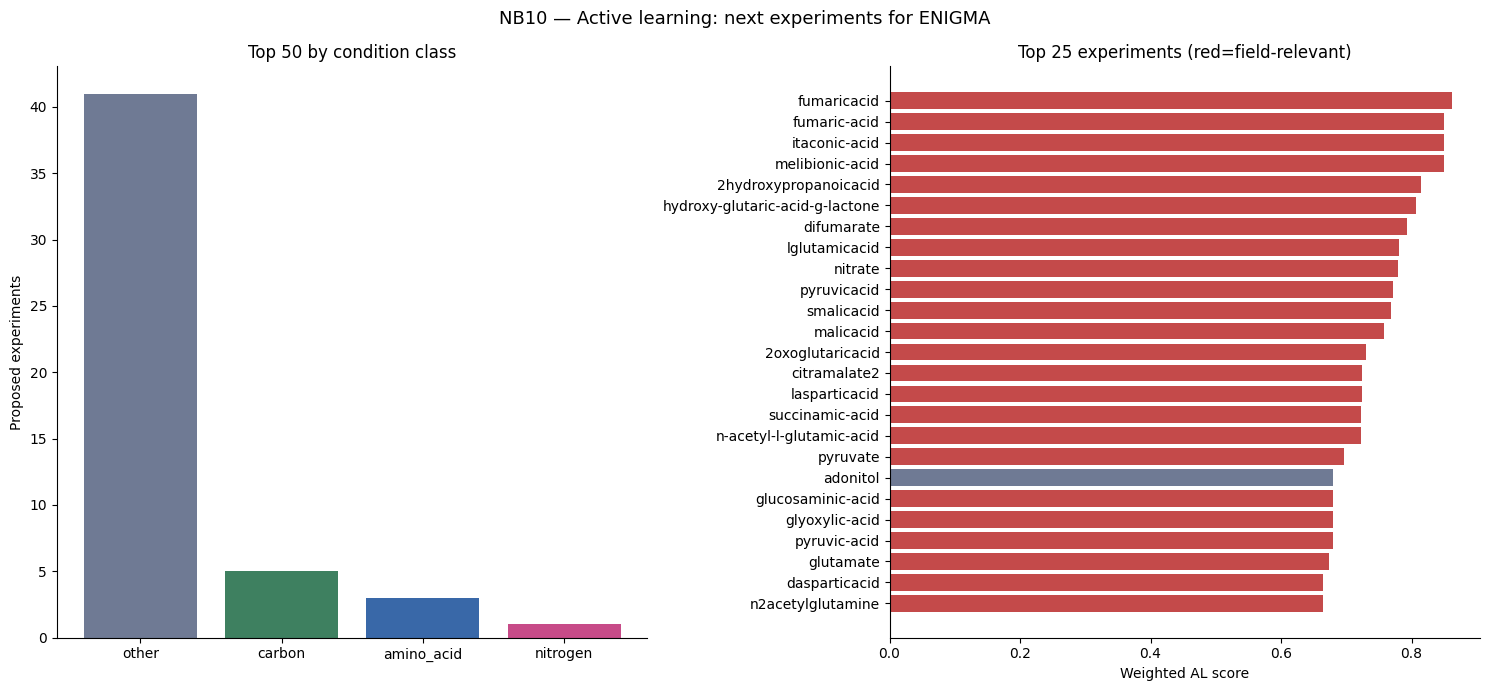

Saved -> figures/NB10_active_learning_proposal.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('NB10 — Active learning: next experiments for ENIGMA', fontsize=13)

# Left: counts by condition class
ax = axes[0]
class_counts = proposed['condition_class'].value_counts()
palette = {'other':'#6f7a94','carbon':'#3e8060','amino_acid':'#3968a8',
           'nitrogen':'#c74b88','nucleoside':'#b07a50','antibiotic':'#888855',
           'metal':'#9063b0'}
colors_l = [palette.get(c, '#888') for c in class_counts.index]
ax.bar(class_counts.index, class_counts.values, color=colors_l)
ax.set_ylabel('Proposed experiments')
ax.set_title('Top 50 by condition class')
for spine in ('right','top'):
    ax.spines[spine].set_visible(False)

# Right: top 25 weighted scores, horizontal, red=field-relevant
ax = axes[1]
top25 = proposed.head(25).copy()
y = np.arange(len(top25))[::-1]
bar_colors = ['#c44a4a' if fw == 2.0 else '#6f7a94' for fw in top25['field_weight']]
ax.barh(y, top25['weighted_score'], color=bar_colors)
ax.set_yticks(y); ax.set_yticklabels(top25['condition'])
ax.set_xlabel('Weighted AL score')
ax.set_title('Top 25 experiments (red=field-relevant)')
for spine in ('right','top'):
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(FIG / 'NB10_active_learning_proposal.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved -> figures/NB10_active_learning_proposal.png')


## 4. Top-10 context

The top 10 recommended conditions are all organic acids or nitrogen-cycle compounds — exactly the classes where the full-corpus GBDT model is weakest (nitrogen AUC 0.435, `other` carbon metabolism AUC 0.654) and where Oak Ridge's geochemistry matters most (nitric-acid-driven pH drop, organic acid accumulation from necromass).

**Recommended test genera**: Prescottella (16 % growth rate, sparse training data) and Microbacterium (23 %) — among the least reliably predicted genera in NB07's genus-blocked holdout, making them the highest-information-gain subjects for new experiments.

The full 50-experiment list is in `data/proposed_experiments.tsv`. H6 (active-learning-ranked > random) requires a retrospective subsampling validation — that is the next step and is not run in this notebook.
